# Spiral Encoding Variants

Comparing three alternatives for how the outside-in spiral of a 7×7 whorl cell
assigns quantile rank to pixel position.  All three use the **same GTEx data**
(approximate bootstrap distributions from `survey.csv`), the same colormap,
and the same 13×20 grid layout as Figure 1.  Only the spiral fill logic changes.

| Variant | Spiral direction | Assignment | Center pixel |
|---|---|---|---|
| **V1 — baseline** | outside → center | sequential quantile rank | max quantile |
| **V2 — median-center** | center → outside | symmetric interleaved rank | median |
| **V3 — mean-center (Keim)** | center → outside | sorted by deviation from mean | mean |

V3 is included to empirically verify the intermingling concern for cells that
straddle zero.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

rng = np.random.default_rng(42)

CMAP = LinearSegmentedColormap.from_list('swo', ['steelblue', 'white', 'orangered'], N=256)
NORM = Normalize(vmin=-1.5, vmax=1.5)

DATA_DIR = Path('../gtex_data')

## Spiral path generators

In [2]:
def spiral_outside_in(n=7):
    """(row, col) pairs in outside-in rectangular spiral order."""
    path, top, bottom, left, right = [], 0, n-1, 0, n-1
    while top <= bottom and left <= right:
        for c in range(left, right+1):  path.append((top, c))
        top += 1
        for r in range(top, bottom+1):  path.append((r, right))
        right -= 1
        if top <= bottom:
            for c in range(right, left-1, -1): path.append((bottom, c))
            bottom -= 1
        if left <= right:
            for r in range(bottom, top-1, -1): path.append((r, left))
            left += 1
    return path

def spiral_inside_out(n=7):
    return list(reversed(spiral_outside_in(n)))

PATH_OUT_IN  = spiral_outside_in(7)  # V1
PATH_IN_OUT  = spiral_inside_out(7)  # V2, V3

N_PIX = 49
print('Spiral path lengths:', len(PATH_OUT_IN), len(PATH_IN_OUT))
print('Center pixel (V1, last):', PATH_OUT_IN[-1])
print('Center pixel (V2/V3, first):', PATH_IN_OUT[0])

Spiral path lengths: 49 49
Center pixel (V1, last): (3, 3)
Center pixel (V2/V3, first): (3, 3)


## Cell rendering — three variants

In [3]:
def render_v1(samples, n=7):
    """V1 — outside-in, sequential quantile rank (baseline)."""
    q = np.linspace(0, 1, N_PIX)
    vals = np.quantile(samples, q)
    img = np.zeros((n, n, 4))
    for i, (r, c) in enumerate(PATH_OUT_IN):
        img[r, c] = CMAP(NORM(vals[i]))
    return img

def render_v2(samples, n=7):
    """V2 — inside-out, symmetric interleaved rank (center = median)."""
    q = np.linspace(0, 1, N_PIX)
    vals = np.quantile(samples, q)
    # Interleave: center gets median, then alternate lower/upper outward
    mid = N_PIX // 2
    interleaved = []
    lo, hi = mid, mid
    interleaved.append(vals[mid])
    for _ in range(mid):
        lo -= 1; interleaved.append(vals[lo])
        hi += 1; interleaved.append(vals[hi])
    img = np.zeros((n, n, 4))
    for i, (r, c) in enumerate(PATH_IN_OUT):
        img[r, c] = CMAP(NORM(interleaved[i]))
    return img

def render_v3(samples, n=7):
    """V3 — inside-out, sorted by |deviation from mean| (Keim). Center = mean.
    
    Uses one representative sample per pixel (evenly spaced after sorting by
    unsigned deviation) rather than averaging a bin — averaging cancels out
    the tails for straddling-zero cells and washes the outer ring to white.
    """
    mean = np.mean(samples)
    order = np.argsort(np.abs(samples - mean))
    sorted_samples = samples[order]
    # Pick one representative per pixel, evenly spaced
    indices = np.linspace(0, len(sorted_samples) - 1, N_PIX, dtype=int)
    vals = sorted_samples[indices]
    img = np.zeros((n, n, 4))
    for i, (r, c) in enumerate(PATH_IN_OUT):
        img[r, c] = CMAP(NORM(vals[i]))
    return img

RENDERERS = {'V1 outside-in\n(baseline)': render_v1,
             'V2 median-center\n(reversed)': render_v2,
             'V3 mean-center\n(Keim)': render_v3}

## Synthesise bootstrap distributions from survey.csv

In [4]:
RIGHT_GENES = [
    'TPH2', 'CHRNA7', 'ESR1',
    'TH', 'SLC6A3', 'DDC', 'AGRP',
    'SST', 'PENK', 'GAD1', 'GAD2', 'CRH',
    'DRD5', 'CHRM1', 'BDNF', 'CYP19A1',
    'AIF1', 'MAOA', 'FKBP5', 'GFAP',
]
REGION_ORDER = [
    'Hypothalamus', 'Amygdala', 'Hippocampus', 'Ant. Cing. Ctx',
    'Frontal Cortex', 'Cortex', 'Caudate', 'Putamen',
    'Nucleus Accumbens', 'Cerebellum', 'Cerebellar Hemi.',
    'Substantia Nigra', 'Spinal Cord',
]

survey = pd.read_csv(DATA_DIR / 'survey.csv')
survey = survey[survey.gene.isin(RIGHT_GENES) & survey.region.isin(REGION_ORDER)]

# Synthesise 5000-sample bootstrap from mean + CI
def synth_bootstrap(row, n=5000):
    se = (row.ci_hi - row.ci_lo) / 3.92  # 95% CI → SE
    return rng.normal(row.mean_md, max(se, 1e-4), n)

bootstraps = {}
for _, row in survey.iterrows():
    bootstraps[(row.gene, row.region)] = synth_bootstrap(row)

print(f'Synthesised {len(bootstraps)} bootstrap distributions')

Synthesised 260 bootstrap distributions


## Algorithm explanation — mapping the bootstrap distribution to the cell

Each panel below shows **the same synthetic bootstrap distribution** (positive mean effect,
moderate spread) encoded by each variant.

**Top row** — the 7×7 cell grid coloured by ring membership (outer → inner = light → dark),
with the spiral traversal path overlaid as an arrow sequence.

**Bottom row** — stacked histogram of the bootstrap samples, bars coloured by which ring
each quantile range maps to.  Read top-to-bottom as outer→center.

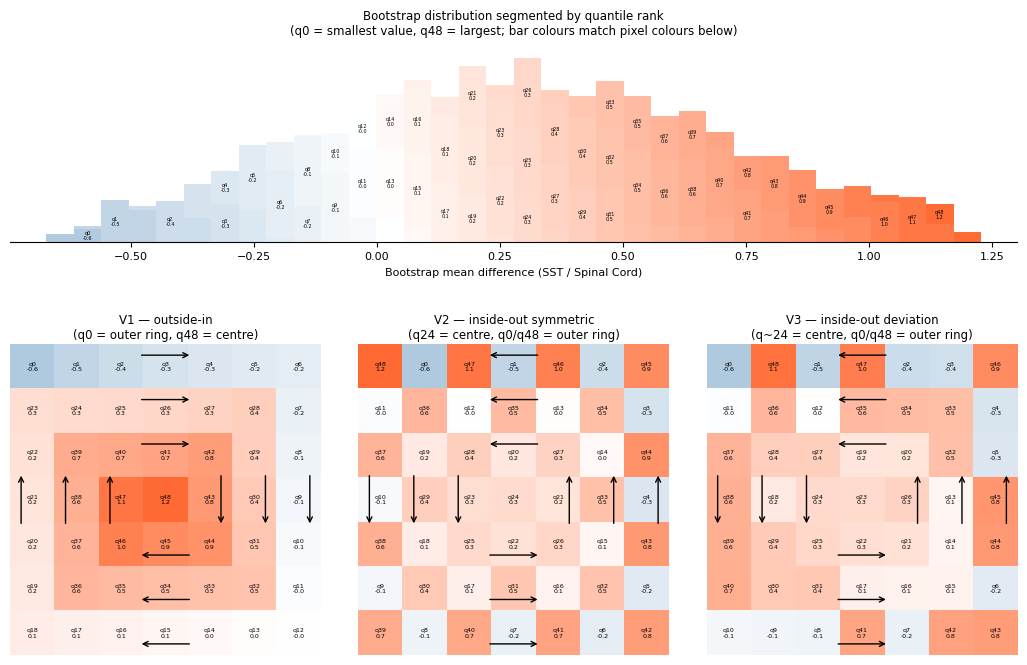

Saved algorithm_explanation.png


In [5]:
# ── Bootstrap: SST / Spinal Cord (same as a1 in zoom figure) ────────────────
bs_sorted = np.sort(bootstraps[('SST', 'Spinal Cord')])
_chop     = int(np.ceil(len(bs_sorted) * 0.025))
bs_c      = bs_sorted[_chop:-_chop]

# ── fv for each variant ───────────────────────────────────────────────────────
def make_fv_v1(bs_c, N=N_PIX):
    ranks = np.linspace(0, len(bs_c), N, dtype=int); ranks[0] = 1
    fv = np.array([bs_c[r-1] for r in ranks])
    if sum(v > 0 for v in bs_c) < len(bs_c) / 2:
        fv = fv[::-1]
    return fv

def make_fv_v2(bs_c, N=N_PIX):
    ranks = np.linspace(0, len(bs_c), N, dtype=int); ranks[0] = 1
    all_q = np.array([bs_c[r-1] for r in ranks])
    mid   = N // 2
    interleaved = [all_q[mid]]
    lo, hi = mid, mid
    for _ in range(mid):
        lo -= 1; interleaved.append(all_q[lo])
        hi += 1; interleaved.append(all_q[hi])
    return np.array(interleaved)

def make_fv_v3(bs_c, N=N_PIX):
    mean      = np.mean(bs_c)
    dev_order = np.argsort(np.abs(bs_c - mean))
    sorted_s  = bs_c[dev_order]
    indices   = np.linspace(0, len(sorted_s)-1, N, dtype=int)
    return sorted_s[indices]

FV_LIST    = [make_fv_v1(bs_c), make_fv_v2(bs_c), make_fv_v3(bs_c)]
PATHS_LIST = [PATH_OUT_IN, PATH_IN_OUT, PATH_IN_OUT]
DNORM      = NORM   # same colormap/norm as spiral_variants_zoom.png

# ── Helpers ───────────────────────────────────────────────────────────────────
def spiralize_grid(fv, path, n=7):
    g = np.full((n, n), np.nan)
    for i, (r, c) in enumerate(path):
        g[r, c] = fv[i]
    return g

def draw_ring_arrows(ax, ring_k, sz, avg_val, clockwise=True):
    """clockwise=True → V1 (outside-in); False → V2/V3 (inside-out)."""
    mid = ring_k + sz // 2
    bg  = CMAP(DNORM(avg_val))
    col = "w" if (0.299*bg[0]+0.587*bg[1]+0.114*bg[2]) < 0.52 else "k"
    ap  = dict(arrowstyle="->", color=col, lw=1.0, mutation_scale=9)
    d, e = 0.25, 0.6
    if clockwise:
        ax.annotate("", xy=(mid+e, ring_k-d),        xytext=(mid-e, ring_k-d),        arrowprops=ap, zorder=8, annotation_clip=False)
        ax.annotate("", xy=(ring_k+sz-1+d, mid+e),   xytext=(ring_k+sz-1+d, mid-e),   arrowprops=ap, zorder=8, annotation_clip=False)
        ax.annotate("", xy=(mid-e, ring_k+sz-1+d),   xytext=(mid+e, ring_k+sz-1+d),   arrowprops=ap, zorder=8, annotation_clip=False)
        ax.annotate("", xy=(ring_k-d, mid-e),         xytext=(ring_k-d, mid+e),         arrowprops=ap, zorder=8, annotation_clip=False)
    else:
        ax.annotate("", xy=(mid-e, ring_k-d),        xytext=(mid+e, ring_k-d),        arrowprops=ap, zorder=8, annotation_clip=False)
        ax.annotate("", xy=(ring_k+sz-1+d, mid-e),   xytext=(ring_k+sz-1+d, mid+e),   arrowprops=ap, zorder=8, annotation_clip=False)
        ax.annotate("", xy=(mid+e, ring_k+sz-1+d),   xytext=(mid-e, ring_k+sz-1+d),   arrowprops=ap, zorder=8, annotation_clip=False)
        ax.annotate("", xy=(ring_k-d, mid+e),         xytext=(ring_k-d, mid-e),         arrowprops=ap, zorder=8, annotation_clip=False)

def draw_algo_cell(ax, fv, path, title, clockwise=True):
    n    = 7
    fv_s = np.sort(fv)
    grid = spiralize_grid(fv, path, n)
    ax.imshow(grid, cmap=CMAP, norm=DNORM, origin="upper",
              interpolation="nearest", aspect="equal")
    # value rank of each pixel (q0 = smallest value, q48 = largest)
    val_rank = np.argsort(np.argsort(fv))
    # ring arrows
    start = 0
    for k in range(n // 2 + 1):
        sz = n - 2*k
        if sz <= 0: break
        end = start + (4*(sz-1) if sz > 1 else 1)
        if sz > 1:
            avg = float(np.mean(fv_s[start:min(end, len(fv_s))]))
            draw_ring_arrows(ax, k, sz, avg, clockwise=clockwise)
        start = end
    # labels: q{value_rank} at each pixel
    for k, (r, c) in enumerate(path):
        vr  = val_rank[k]
        val = float(fv[k])
        bg  = CMAP(DNORM(val))
        lum = 0.299*bg[0]+0.587*bg[1]+0.114*bg[2]
        tc  = "w" if lum < 0.52 else "k"
        ax.text(c, r, f"q{vr}\n{val:.1f}",
                ha="center", va="center", fontsize=4.5, color=tc,
                zorder=10, linespacing=1.1, multialignment="center")
    ax.set_xlim(-0.5, n-0.5); ax.set_ylim(n-0.5, -0.5)
    ax.axis("off")
    ax.set_title(title, fontsize=8.5, pad=4)

def draw_shared_hist(ax, bs_c, fv):
    """Single histogram shared by all variants.
    q-labels are value rank: q0 = leftmost (smallest), q48 = rightmost (largest)."""
    N    = len(fv)
    fv_s = np.sort(fv)
    span = fv_s[-1] - fv_s[0]
    xl0  = fv_s[0]  - span*0.05
    xl1  = fv_s[-1] + span*0.05
    BW   = (xl1 - xl0) / 36
    bins = np.arange(xl0, xl1+BW, BW)
    counts, _ = np.histogram(np.clip(bs_c, xl0, xl1), bins=bins, density=True)

    # segment boundaries = midpoints between consecutive sorted fv values
    seg_bounds    = np.empty(N+1)
    seg_bounds[0] = xl0; seg_bounds[-1] = xl1
    for k in range(1, N):
        seg_bounds[k] = (fv_s[k-1]+fv_s[k]) / 2.0
    seg_cols = [CMAP(DNORM(float(v))) for v in fv_s]

    best_piece = {}
    for lo, hi, ht in zip(bins[:-1], bins[1:], counts):
        if ht == 0: continue
        y_bot = 0.0
        for k in range(N):
            ov = max(0., min(hi, seg_bounds[k+1]) - max(lo, seg_bounds[k]))
            if ov <= 0: continue
            h = ht * ov / (hi-lo)
            ax.bar(lo, h, width=hi-lo, bottom=y_bot, align="edge",
                   color=seg_cols[k], edgecolor="none")
            if k not in best_piece or h > best_piece[k][2]:
                best_piece[k] = (lo+(hi-lo)/2, y_bot, h)
            y_bot += h

    # q-labels by value rank (q0 = leftmost bar)
    for k, (xc, yb, h) in best_piece.items():
        if h < counts.max()*0.005: continue
        col = seg_cols[k]; lum = 0.299*col[0]+0.587*col[1]+0.114*col[2]
        tc  = "w" if lum < 0.52 else "k"
        ax.text(xc, yb+h/2, f"q{k}\n{fv_s[k]:.1f}",
                ha="center", va="center", fontsize=3.5, color=tc,
                zorder=11, linespacing=1.0, multialignment="center")

    ax.set_xlim(fv_s[0]-span*0.06, fv_s[-1]+span*0.06)
    ax.set_ylim(0, counts.max()*1.08)
    for sp in ["left","right","top"]: ax.spines[sp].set_visible(False)
    ax.set_yticks([]); ax.tick_params(labelsize=8)
    ax.set_xlabel("Bootstrap mean difference (SST / Spinal Cord)", fontsize=8)
    ax.set_title("Bootstrap distribution segmented by quantile rank\n"
                 "(q0 = smallest value, q48 = largest; bar colours match pixel colours below)",
                 fontsize=8.5)

# ── Figure: histogram on top, three cells below ───────────────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13, 8))
gs  = GridSpec(2, 3, figure=fig,
               height_ratios=[1, 1.6],
               hspace=0.38, wspace=0.12)

ax_hist = fig.add_subplot(gs[0, :])   # full-width top row
draw_shared_hist(ax_hist, bs_c, FV_LIST[0])   # V1 fv = cleanest q ordering

TITLES_CELL = [
    "V1 — outside-in\n(q0 = outer ring, q48 = centre)",
    "V2 — inside-out symmetric\n(q24 = centre, q0/q48 = outer ring)",
    "V3 — inside-out deviation\n(q~24 = centre, q0/q48 = outer ring)",
]
CLOCKWISE = [True, False, False]

for col, (fv, path, tc, cw) in enumerate(
        zip(FV_LIST, PATHS_LIST, TITLES_CELL, CLOCKWISE)):
    ax = fig.add_subplot(gs[1, col])
    draw_algo_cell(ax, fv, path, tc, clockwise=cw)

plt.savefig("algorithm_explanation.png", dpi=600, bbox_inches="tight")
plt.show()
print("Saved algorithm_explanation.png")


**Figure legend — Spiral encoding variants**

*Top row — Cell ring maps.* Each 7×7 pixel grid represents one whorl cell.
Pixels are shaded from light (outermost ring, 24 pixels) to dark (centre, 1 pixel).
White arrows trace the spiral traversal path; the circle marks the first pixel visited
and the star marks the last (and therefore the most recently assigned quantile value).

*Bottom row — Bootstrap distribution by ring.* Bars show the same synthetic
bootstrap distribution (positive mean effect, moderate spread; mean ≈ 0.65, SD ≈ 0.28,
n = 5 000 resamples), with each bar coloured by the ring that receives those samples
under each variant.  The dashed vertical line marks zero effect.

**V1 — Outside-in baseline.** The spiral visits pixels from the outermost ring
inward.  Quantile ranks are assigned sequentially (rank 0 → first outer pixel,
rank 48 → centre pixel), so the lowest-effect samples (left tail of the
distribution) populate the outer ring and the highest-effect samples concentrate
at the centre.  For a purely positive effect the centre is the most saturated red
pixel; for a purely negative effect it is the most saturated blue.  This is the
encoding used in the current whorlmap implementation.

**V2 — Inside-out symmetric (centre = median).** The spiral path is reversed
(visits centre first) and quantile ranks are interleaved symmetrically: the median
(rank 24) is assigned to the centre pixel, then ranks 23 and 25 to the next ring,
22 and 26 to the ring after, and so on.  Both distributional tails therefore
appear in the outer ring, while the centre encodes the median — the conventional
point estimate.  Scanning the centre pixel of each cell across the full grid gives
a scalar-heatmap-like read of median effects without losing distributional
information in the surrounding rings.

**V3 — Inside-out deviation from mean (Keim 2000).** Following the query-dependent
pixel arrangement formalised by Keim (2000, Definition 2), samples are sorted by
their unsigned deviation from the bootstrap mean.  The sample nearest the mean maps
to the centre pixel; samples furthest from the mean map to the outer ring.  Because
the sort is unsigned, samples from the positive tail and the negative tail both end
up in the outer ring, creating colour intermingling (adjacent red and blue pixels)
for any cell whose distribution straddles zero.  For strongly unidirectional effects
the intermingling is absent and the outer ring is saturated in one colour, but for
near-null or bimodal cells the outer ring becomes a red–blue mosaic that is hard to
interpret.  V3 is included here as the theoretically-motivated alternative but is
not recommended for this application.

## Highlighted cells at 10× zoom

The four cells from Figure 1 (a1, a2, b1, b2) shown at 10× magnification
to make the pixel-level structure legible.

| Label | Gene | Region | Expected character |
|---|---|---|---|
| a1 | SST | Spinal Cord | strong directional |
| a2 | FKBP5 | Putamen | crosses zero |
| b1 | AIF1 | Substantia Nigra | strong directional |
| b2 | CYP19A1 | Caudate | mixed / moderate |

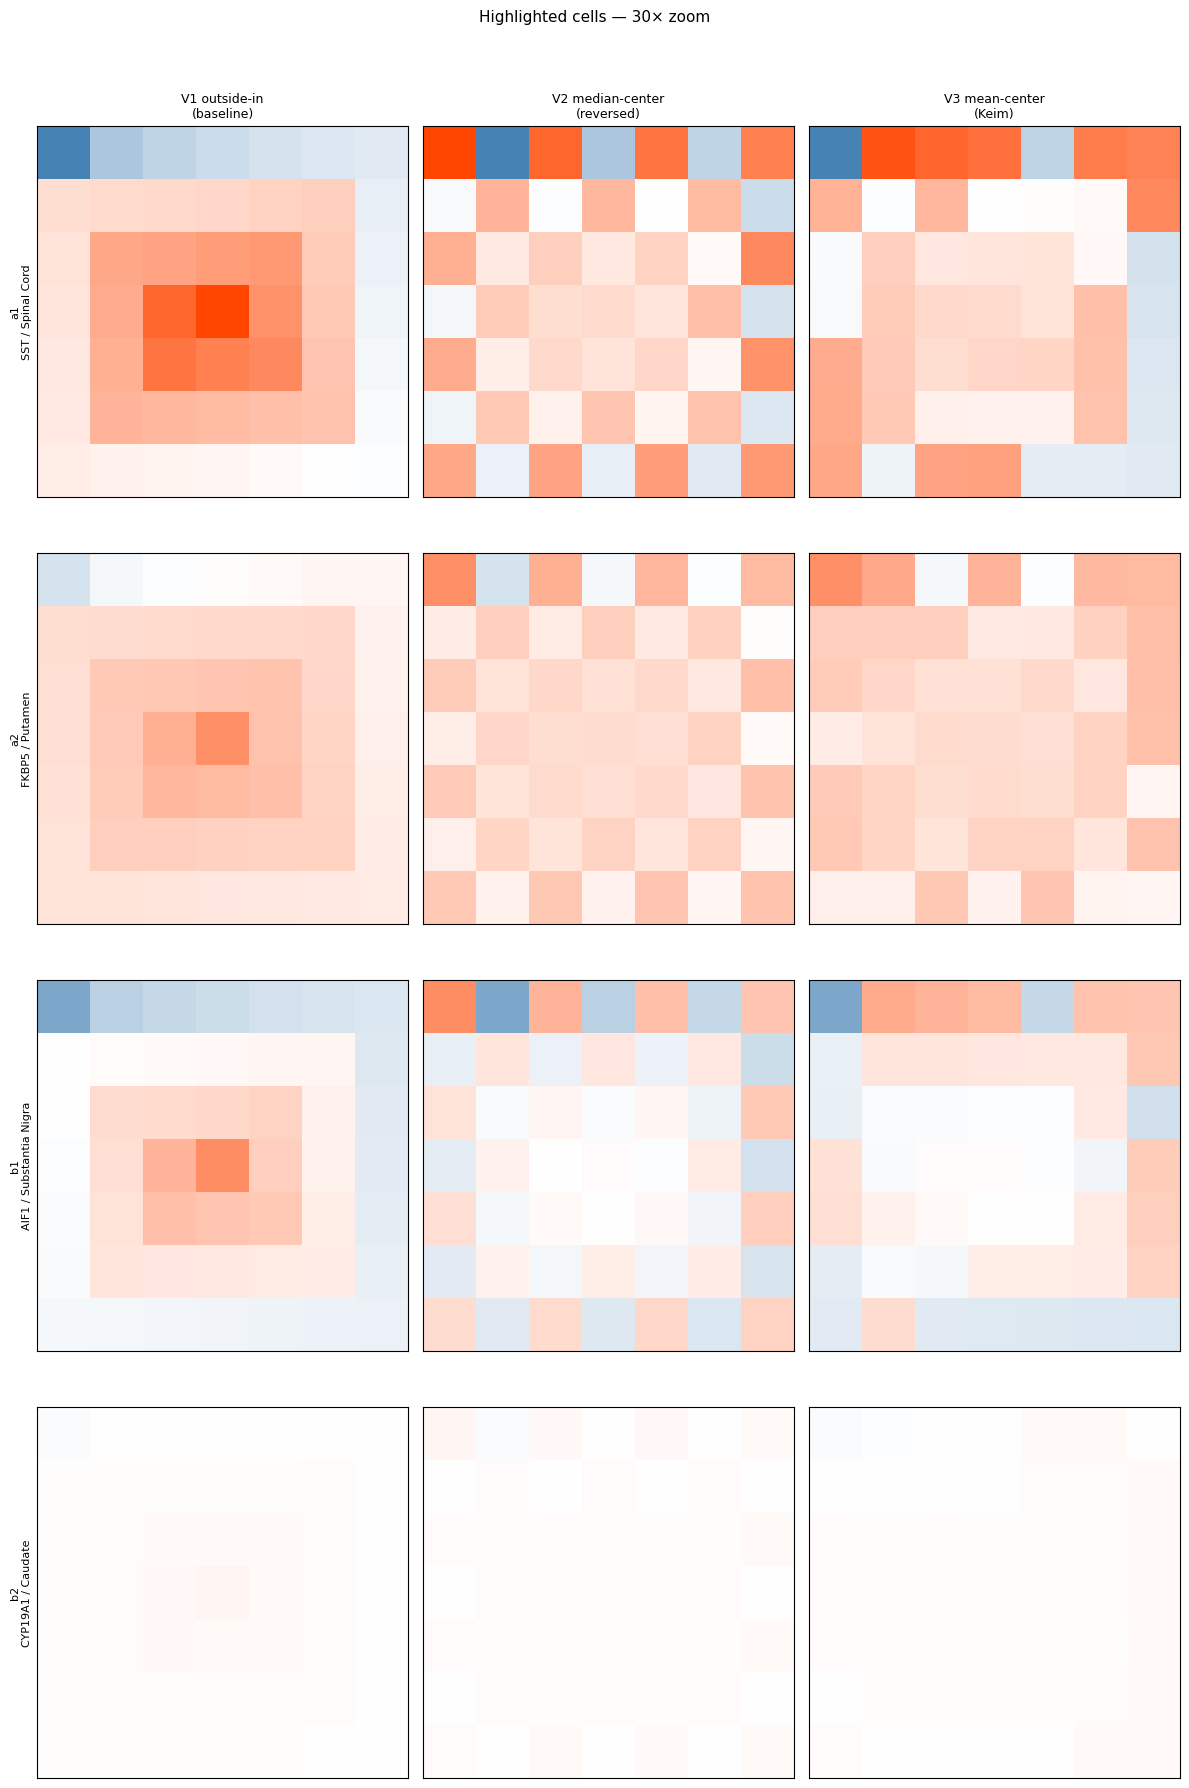

Saved spiral_variants_zoom.png


In [6]:
HIGHLIGHT = [
    ('a1', 'SST',     'Spinal Cord'),
    ('a2', 'FKBP5',   'Putamen'),
    ('b1', 'AIF1',    'Substantia Nigra'),
    ('b2', 'CYP19A1', 'Caudate'),
]
ZOOM_CELL = 30  # pixels per whorl pixel → each cell shown at 210×210 px

fig, axes = plt.subplots(len(HIGHLIGHT), len(RENDERERS),
                          figsize=(4 * len(RENDERERS), 4.5 * len(HIGHLIGHT)))

for row_i, (label, gene, region) in enumerate(HIGHLIGHT):
    samples = bootstraps[(gene, region)]
    for col_j, (vname, renderer) in enumerate(RENDERERS.items()):
        ax = axes[row_i, col_j]
        cell_img = renderer(samples)
        cell_big = np.repeat(np.repeat(cell_img, ZOOM_CELL, axis=0), ZOOM_CELL, axis=1)
        ax.imshow(cell_big, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        if row_i == 0:
            ax.set_title(vname, fontsize=9)
        if col_j == 0:
            ax.set_ylabel(f'{label}\n{gene} / {region}', fontsize=8)

plt.suptitle('Highlighted cells — 30× zoom', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('spiral_variants_zoom.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved spiral_variants_zoom.png')

## Full 13×20 whorlmap — all three variants

The three maps below use identical data; only the fill logic differs. Look especially at cells that straddle zero (V3 intermingling) vs.
cells with strong directional effects (V1 vs V2 gradient direction). **Click on the pictures to see larger versions.**

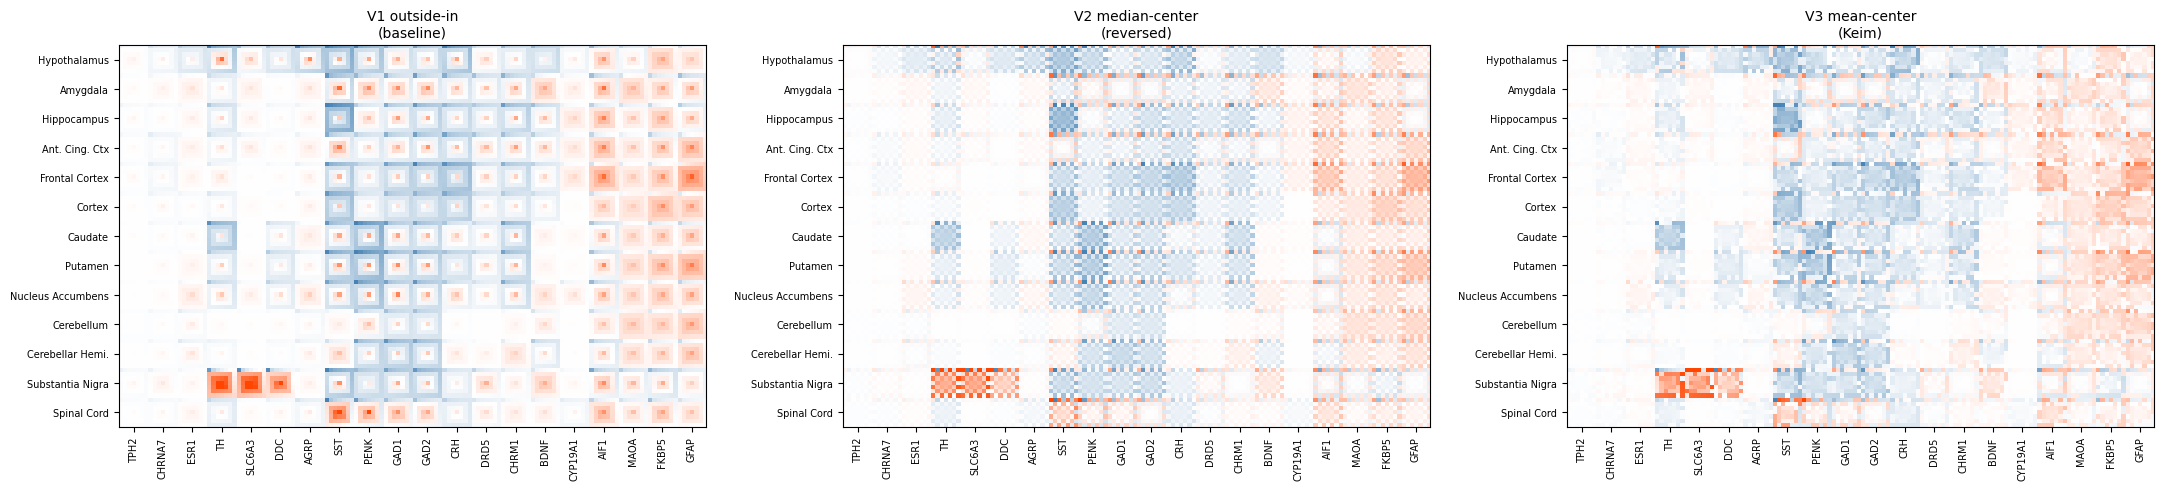

Saved spiral_variants_fullmap.png


In [7]:
ZOOM = 8  # pixels per whorl-cell pixel → each cell = 56×56 px in the map

def draw_whorlmap(renderer, ax, title):
    nrow, ncol = len(REGION_ORDER), len(RIGHT_GENES)
    canvas = np.ones((nrow * 7 * ZOOM, ncol * 7 * ZOOM, 4))
    
    for ri, region in enumerate(REGION_ORDER):
        for ci, gene in enumerate(RIGHT_GENES):
            key = (gene, region)
            if key not in bootstraps:
                continue
            cell_img = renderer(bootstraps[key])  # 7×7×4
            # Scale up by ZOOM
            cell_big = np.repeat(np.repeat(cell_img, ZOOM, axis=0), ZOOM, axis=1)
            r0, c0 = ri * 7 * ZOOM, ci * 7 * ZOOM
            canvas[r0:r0 + 7*ZOOM, c0:c0 + 7*ZOOM] = cell_big
    
    ax.imshow(canvas, interpolation='nearest', aspect='equal')
    ax.set_xticks(np.arange(ncol) * 7 * ZOOM + 3.5 * ZOOM)
    ax.set_xticklabels(RIGHT_GENES, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(nrow) * 7 * ZOOM + 3.5 * ZOOM)
    ax.set_yticklabels(REGION_ORDER, fontsize=7)
    ax.set_title(title, fontsize=10, pad=6)

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
for ax, (label, renderer) in zip(axes, RENDERERS.items()):
    draw_whorlmap(renderer, ax, label)

plt.tight_layout(pad=2)
plt.savefig('spiral_variants_fullmap.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved spiral_variants_fullmap.png')

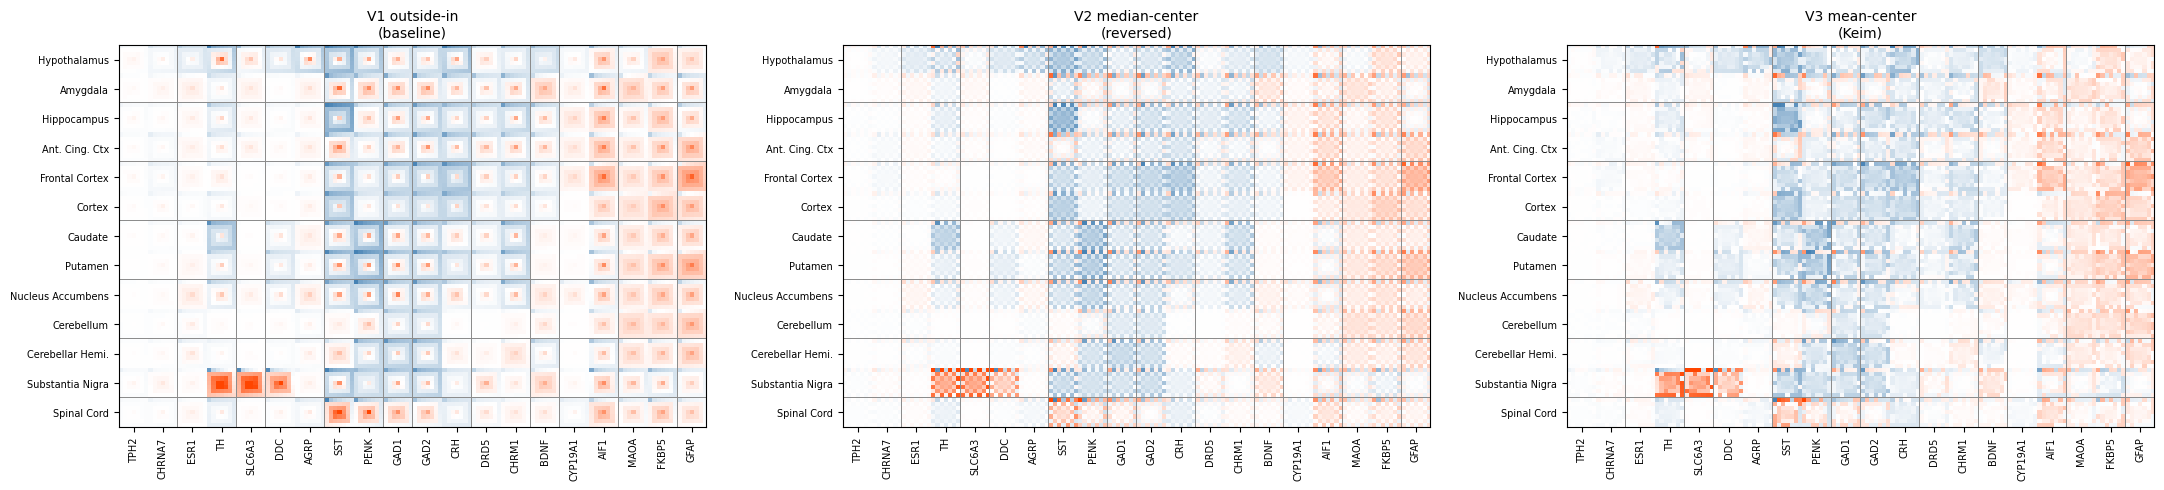

Saved spiral_variants_borders.png


In [8]:
# ── Additional figure: cell borders baked into canvas (pixel-perfect) ────────
# V1 shown without borders to demonstrate that the outside-in spiral creates
# natural implicit framing; all three shown WITH borders in this figure.

GRAY = np.array([0.55, 0.55, 0.55, 1.0])   # border colour

def draw_whorlmap_with_border(renderer, ax, title, add_border=False):
    nrow, ncol = len(REGION_ORDER), len(RIGHT_GENES)
    canvas = np.ones((nrow * 7 * ZOOM, ncol * 7 * ZOOM, 4))

    for ri, region in enumerate(REGION_ORDER):
        for ci, gene in enumerate(RIGHT_GENES):
            key = (gene, region)
            if key not in bootstraps:
                continue
            cell_img = renderer(bootstraps[key])
            cell_big = np.repeat(np.repeat(cell_img, ZOOM, axis=0), ZOOM, axis=1)
            r0, c0 = ri * 7 * ZOOM, ci * 7 * ZOOM
            canvas[r0:r0 + 7*ZOOM, c0:c0 + 7*ZOOM] = cell_big

    if add_border:
        # Paint 1-pixel gray lines at every cell boundary, directly in the canvas
        for i in range(1, nrow):
            canvas[i * 7 * ZOOM - 1, :] = GRAY   # last pixel row of cell i-1
        for j in range(1, ncol):
            canvas[:, j * 7 * ZOOM - 1] = GRAY   # last pixel col of cell j-1

    ax.imshow(canvas, interpolation='nearest', aspect='equal')
    ax.set_xticks(np.arange(ncol) * 7 * ZOOM + 3.5 * ZOOM)
    ax.set_xticklabels(RIGHT_GENES, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(nrow) * 7 * ZOOM + 3.5 * ZOOM)
    ax.set_yticklabels(REGION_ORDER, fontsize=7)
    ax.set_title(title, fontsize=10, pad=6)

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
for ax, (label, renderer) in zip(axes, RENDERERS.items()):
    draw_whorlmap_with_border(renderer, ax, label, add_border=True)

plt.tight_layout(pad=2)
plt.savefig('spiral_variants_borders.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved spiral_variants_borders.png')


**Cell borders.** In V1 (outside-in spiral), the outermost ring of each cell acts as a natural frame: adjacent cells meet edge-to-edge at their dimmest, most peripheral pixels, creating an implicit boundary that the eye resolves without any overlay. In V2 and V3 (inside-out), the outermost ring instead carries the most deviated values — the same saturated colours that appear at the centre of strongly-affected cells. When two such cells are adjacent, their outer rings can share nearly identical hues and the cell boundary becomes ambiguous. V3 in particular follows the centre-dominant arrangement formalised in [@keim2000], which places the most query-relevant data at the centre; a consequence is that the outer ring aggregates the most extreme values from both tails, making implicit cell separation impossible. A thin 1-pixel gray separator (painted directly into the canvas, one pixel inside each cell boundary) restores legibility without affecting colour fidelity inside the cells.

## Observations

Record visual observations here after running.

- V1 vs V2: does reversing the spiral change readability of the full map?
- V2: is the median visually salient at the center?
- V3: is intermingling visible in straddling-zero cells (a2)?
- Which variant best supports quick scanning of the full 13×20 grid?